# JointPMF Data 

In [1]:
import os
from tqdm import tqdm
import sys
if not hasattr(sys.modules[__name__], "cwd_changed"):
    os.chdir(os.path.dirname(os.path.dirname(os.path.abspath(__name__))))
    sys.modules[__name__].cwd_changed = True

import warnings 
warnings.filterwarnings("ignore")
import logging
logging.getLogger('pgmpy').setLevel(logging.WARNING)


import pandas as pd
from utils.graph import dag_to_cpdag
# from metrics.graph import compare_dags
from utils.results import *
from analyses.helpers import load_results


In [2]:
import pickle
import matplotlib as mpl
import matplotlib.pyplot as plt

subset = 'binary_data'

def load_results(subset, base_dir= "results", ):
    global results_by_label

    with open(f'{base_dir}/pc/{subset}.pkl', 'rb') as f:
        results_pc = pickle.load(f)
    
    with open(f'{base_dir}/pc_gsq/{subset}.pkl', 'rb') as f:
        results_pc_gsq = pickle.load(f)
    

    with open(f'{base_dir}/ges/{subset}.pkl', 'rb') as f:
        results_ges = pickle.load(f)
    
    with open(f'{base_dir}/hc/{subset}.pkl', 'rb') as f:
        results_hc = pickle.load(f)

    with open(f'{base_dir}/ea_fg/{subset}.pkl', 'rb') as f:
        results_ea_fg = pickle.load(f)

    with open(f'{base_dir}/ea_hc/{subset}.pkl', 'rb') as f:
        results_ea_hc = pickle.load(f)
        
    with open(f'results/ea_ues/{subset}.pkl', 'rb') as f:
        results_ea_ues = pickle.load(f)

    with open(f'results/ea_ies/{subset}.pkl', 'rb') as f:
        results_ea_ies = pickle.load(f)
    
    with open(f'results/ea_fes/{subset}.pkl', 'rb') as f:
        results_ea_fes = pickle.load(f)


    results_by_label = {
        "PC": results_pc,
        "PC-GSQ": results_pc_gsq,   
        "GES": results_ges,
        "HC": results_hc,
        "EA-HC": results_ea_hc,
        "EA-Base": results_ea_ues,
        "EA-IES": results_ea_ies,
        "EA-FES": results_ea_fes,
        "EA-FG": results_ea_fg,
        # "NOTEARS": results_notears,
        }



mpl.rcParams.update({
    'font.family'         : 'serif',       # Computer Modern — the default LaTeX font
    'font.size'           : 12,            # body text size (most journals use 10 pt)
    'axes.labelsize'      : 12,            # axis-label size matches body text
    'xtick.labelsize'     : 12,             # tick labels one point smaller
    'ytick.labelsize'     : 12,
    'legend.fontsize'     : 12,             # legend text one point smaller
    'axes.prop_cycle'     : mpl.cycler('color', [   # Okabe–Ito colorblind-safe palette
        '#0072B2', '#D55E00', '#009E73',
        '#E69F00', '#CC79A7', '#56B4E9',
    ]),
    'lines.linewidth'     : 1.5,           # slightly thicker for print clarity
    'axes.linewidth'      : 0.8,           # thinner axis frame
    'xtick.direction'     : 'in',          # inward ticks — journal standard
    'ytick.direction'     : 'in',
    'xtick.minor.visible' : True,          # show minor ticks
    'ytick.minor.visible' : True,
    'xtick.major.size'    : 4,             # longer than the 3.5 default
    'ytick.major.size'    : 4,
    # 'xtick.minor.size'    : 2,             # half of major — proportional
    # 'ytick.minor.size'    : 2,
    'xtick.major.width'   : 0.8,           # match axes.linewidth
    'ytick.major.width'   : 0.8,
    'xtick.minor.width'   : 0.6,           # thinner for visual hierarchy
    'ytick.minor.width'   : 0.6,
    'lines.markersize'    : 4,             # smaller markers for print scale
    'errorbar.capsize'    : 3,             # visible end-caps (default is 0)
    # 'axes.xmargin'        : 0.02,          # hug the data (default is 0.05)
    # 'axes.ymargin'        : 0.02,
    'legend.frameon'      : False,         # no legend box
    'savefig.bbox'        : 'tight',       # tight bounding box by default
    'savefig.dpi'         : 600,           # publication-quality resolution
    **(                                    # LaTeX if installed, else fallback
        {'text.usetex'        : True,              # real LaTeX for all text
         'text.latex.preamble': r'\usepackage{amsmath} \usepackage{amssymb}',
         'pgf.texsystem'     : 'pdflatex',         # consistent PGF export
         'pgf.rcfonts'       : False}               # let LaTeX control fonts
        if __import__('shutil').which('latex') else
        {'text.usetex'        : False,             # no TeX install found
         'mathtext.fontset'  : 'cm'}               # Computer Modern via mathtext
    ),
})


In [3]:
## new plot code

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import Normalize


def pivot_grid(df, index, column, value_col, aggfunc="mean"):
    return df.pivot_table(index=index, columns=column, values=value_col, aggfunc=aggfunc)


def _iqr(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    return np.nanpercentile(x, 75) - np.nanpercentile(x, 25)


def plot_heatmap_from_grid(
    grid,
    title,
    xlabel=None,
    ylabel=None,
    cbar_label=None,
    ax=None,
    vmin=None,
    vmax=None,
    cmap=None,
    norm=None,
    add_colorbar=True,
    annot_grid=None,
    fmt="{:.2f}",
    iqr_fmt="{:.2f}",
    text_size=8,
):
    """Matplotlib heatmap from a pivoted grid DataFrame, with optional shared scaling and cell annotations."""
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure

    data = grid.to_numpy(dtype=float)

    if norm is None:
        im = ax.imshow(
            data,
            aspect="auto",
            origin="upper",
            vmin=vmin,
            vmax=vmax,
            cmap=cmap,
        )
    else:
        im = ax.imshow(
            data,
            aspect="auto",
            origin="upper",
            norm=norm,
            cmap=cmap,
        )

    if add_colorbar:
        cb = fig.colorbar(im, ax=ax)
        cb.set_label(cbar_label or "")

    x_pos = np.arange(len(grid.columns))
    y_pos = np.arange(len(grid.index))
    ax.set_xticks(x_pos)
    ax.set_yticks(y_pos)

    def _is_numeric_seq(seq):
        try:
            _ = np.asarray(seq, dtype=float)
            return True
        except Exception:
            return False

    cols = list(grid.columns)
    rows = list(grid.index)

    cols_numeric = _is_numeric_seq(cols)
    rows_numeric = _is_numeric_seq(rows)

    if cols_numeric:
        col_vals = np.asarray(cols, dtype=float)
        use_sci = (np.nanmax(np.abs(col_vals)) >= 1e5) or (
            np.nanmin(np.abs(col_vals[np.nonzero(col_vals)])) < 1e-2
            if np.any(col_vals != 0) else False
        )

        if use_sci:
            ax.xaxis.set_major_formatter(
                mticker.FuncFormatter(
                    lambda i, _: f"{col_vals[int(round(i))]:.0e}"
                    if 0 <= int(round(i)) < len(col_vals) else ""
                )
            )
        else:
            ax.xaxis.set_major_formatter(
                mticker.FuncFormatter(
                    lambda i, _: f"{col_vals[int(round(i))]:g}"
                    if 0 <= int(round(i)) < len(col_vals) else ""
                )
            )
    else:
        ax.xaxis.set_major_formatter(
            mticker.FuncFormatter(
                lambda i, _: str(cols[int(round(i))])
                if 0 <= int(round(i)) < len(cols) else ""
            )
        )

    if rows_numeric:
        row_vals = np.asarray(rows, dtype=float)
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(
                lambda i, _: f"{row_vals[int(round(i))]:g}"
                if 0 <= int(round(i)) < len(row_vals) else ""
            )
        )
    else:
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(
                lambda i, _: str(rows[int(round(i))])
                if 0 <= int(round(i)) < len(rows) else ""
            )
        )

    ax.set_xlabel(xlabel or "")
    ax.set_ylabel(ylabel or "")
    ax.set_title(title)

    ax.tick_params(axis="x", labelrotation=45)
    ax.tick_params(axis="both", which="major", labelsize=9)

    # ---- annotations: mean and IQR ----
    if annot_grid is not None:
        annot_vals = annot_grid.to_numpy(dtype=float)

        finite_vals = data[np.isfinite(data)]
        midpoint = np.nanmean(finite_vals) if finite_vals.size else 0.0

        for r in range(data.shape[0]):
            for c in range(data.shape[1]):
                mean_val = data[r, c]
                iqr_val = annot_vals[r, c]

                if not np.isfinite(mean_val):
                    continue

                text = fmt.format(mean_val)
                if np.isfinite(iqr_val):
                    text += "\n[" + iqr_fmt.format(iqr_val) + "]"

                color = "white" if mean_val < midpoint else "black"
                ax.text(
                    c, r, text,
                    ha="center", va="center",
                    fontsize=text_size,
                    color=color,
                )

    return fig, ax, im


def _global_minmax(arrays, robust=False, q=(2, 98), symmetric=False):
    vals = []
    for a in arrays:
        if a is None:
            continue
        flat = np.asarray(a, dtype=float).ravel()
        flat = flat[np.isfinite(flat)]
        if flat.size:
            vals.append(flat)
    if not vals:
        return None, None

    allv = np.concatenate(vals)

    if robust:
        lo, hi = np.nanpercentile(allv, [q[0], q[1]])
    else:
        lo, hi = np.nanmin(allv), np.nanmax(allv)

    if symmetric:
        m = np.nanmax(np.abs([lo, hi]))
        return -m, m
    return lo, hi


def plot_final_heatmap(
    long_df,
    plot_metric,
    x_col="samples",
    y_col="p_noise",
    x_label=None,
    y_label=None,
    ncols=None,
    filter=None,
    aggfunc="mean",
    figsize_per_col=(5, 4),
    sharey=True,
    standardize_colors=True,
    robust=False,
    robust_q=(2, 98),
    symmetric=False,
    fixed_vmin=None,
    fixed_vmax=None,
    cmap=None,
    single_colorbar=True,
    show_iqr=True,
    mean_fmt="{:.2f}",
    iqr_fmt="{:.2f}",
    text_size=8,
):
    """
    Plot heatmaps for an arbitrary number of algorithms/results, with standardized colors.
    Each cell can be annotated with mean and IQR.
    """
    labels = list(long_df["Algorithm"].unique())
    k = len(labels)

    if ncols is None:
        ncols = min(4, k)
    nrows = (k + ncols - 1) // ncols

    fig_w = figsize_per_col[0] * ncols
    fig_h = figsize_per_col[1] * nrows
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(fig_w, fig_h),
        constrained_layout=True,
        sharey=sharey
    )

    axes_list = [axes] if k == 1 else list(np.ravel(axes))

    grids_by_label = {}
    iqr_grids_by_label = {}
    grid_arrays = []

    for label in labels:
        df = long_df[long_df["Algorithm"] == label]
        if filter is not None:
            filter_col, filter_val = filter
            df = df[df[filter_col] == filter_val]

        mean_grid = pivot_grid(df, index=y_col, column=x_col, value_col=plot_metric, aggfunc=aggfunc)
        grids_by_label[label] = mean_grid
        grid_arrays.append(mean_grid.to_numpy(dtype=float))

        if show_iqr:
            iqr_grid = pivot_grid(df, index=y_col, column=x_col, value_col=plot_metric, aggfunc=_iqr)
            iqr_grids_by_label[label] = iqr_grid
        else:
            iqr_grids_by_label[label] = None

    vmin = vmax = None
    norm = None
    if standardize_colors:
        if fixed_vmin is not None or fixed_vmax is not None:
            vmin = fixed_vmin
            vmax = fixed_vmax
        else:
            vmin, vmax = _global_minmax(
                grid_arrays,
                robust=robust,
                q=robust_q,
                symmetric=symmetric
            )
        norm = Normalize(vmin=vmin, vmax=vmax) if (vmin is not None and vmax is not None) else None

    last_im = None
    for i, label in enumerate(labels):
        ax = axes_list[i]
        grid = grids_by_label[label]
        iqr_grid = iqr_grids_by_label[label]

        _, _, im = plot_heatmap_from_grid(
            grid,
            title=f"{label} – {plot_metric}",
            cbar_label=plot_metric,
            ax=ax,
            cmap=cmap,
            norm=norm if standardize_colors else None,
            vmin=None if standardize_colors else fixed_vmin,
            vmax=None if standardize_colors else fixed_vmax,
            add_colorbar=(not single_colorbar) or (not standardize_colors),
            annot_grid=iqr_grid,
            fmt=mean_fmt,
            iqr_fmt=iqr_fmt,
            text_size=text_size,
        )
        ax.set_xlabel(x_col if x_label is None else x_label)
        ax.set_ylabel(y_col if y_label is None else y_label)
        last_im = im

    for j in range(k, len(axes_list)):
        axes_list[j].set_visible(False)

    if standardize_colors and single_colorbar and last_im is not None:
        cb = fig.colorbar(last_im, ax=[ax for ax in axes_list[:k]], shrink=0.9)
        cb.set_label(plot_metric)

    return fig, axes

In [4]:
# subset = "jpmf_data"
subset = "binary_data"
load_results(subset)


In [5]:
algo_results = results_by_label["EA-FG"]

In [6]:
dir(algo_results[0])

['__annotations__',
 '__class__',
 '__dataclass_fields__',
 '__dataclass_params__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__match_args__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'algorithm',
 'bic_scores',
 'df_by_id',
 'ea_configurations',
 'eval_metrics',
 'experiment1_results',
 'experiment2_results',
 'folder',
 'learned_graphs',
 'max_score',
 'metadata_by_id',
 'replications',
 'true_graphs']

In [7]:
# jaccard similarity code 

from itertools import combinations
import numpy as np


def jaccard_similarity(set_a, set_b):
    """Compute Jaccard similarity between two sets."""
    union = set_a | set_b
    if not union:
        return 1.0  # both empty -> treat as perfect agreement
    return len(set_a & set_b) / len(union)


def pairwise_jaccard_similarities(sets):
    """
    Compute Jaccard similarity for all distinct pairs in a list of sets.

    Parameters
    ----------
    sets : list[set]
        One set per run.

    Returns
    -------
    list[float]
        Pairwise Jaccard similarities.
    """
    return [
        jaccard_similarity(sets[i], sets[j])
        for i, j in combinations(range(len(sets)), 2)
    ]


def mean_pairwise_jaccard(sets):
    """
    Compute mean pairwise Jaccard similarity across all runs.
    """
    sims = pairwise_jaccard_similarities(sets)
    return float(np.mean(sims)) if sims else np.nan

## Check Jaccard Similarity for Found and Missing Colliders 

In [8]:
from metrics.graph import evaluate_colliders

idx = 250
all_learned_graphs = [res.learned_graphs[idx] for res in algo_results]
graph_sets = [evaluate_colliders(algo_results[0].metadata_by_id[idx], g, algo_results[0].df_by_id[idx], return_sets=True) for g in all_learned_graphs]

TypeError: evaluate_colliders() got an unexpected keyword argument 'return_sets'

In [ ]:

# graph_sets = {}
# for idx in algo_results[0].learned_graphs.keys():
#     all_learned_graphs = [res.learned_graphs[idx] for res in algo_results]
#     graph_sets[idx] = [evaluate_colliders(algo_results[0].metadata_by_id[idx], g, algo_results[0].df_by_id[idx]) for g in all_learned_graphs]



KeyboardInterrupt: 

In [ ]:
graph_sets

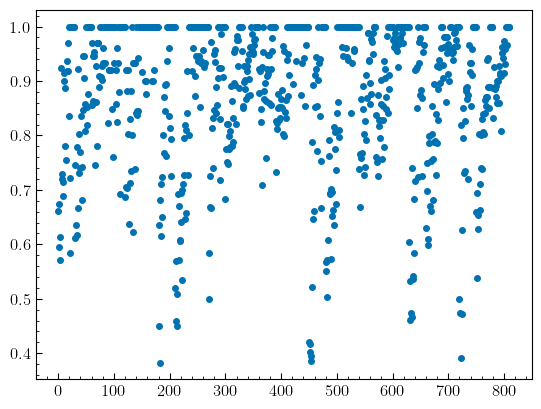

In [9]:
# idx = 89

jac_by_id = {}
for idx in algo_results[0].learned_graphs.keys():
    all_learned_graphs = [i.learned_graphs[idx] for i in algo_results]
    all_learned_edges = [set(g.edges()) for g in all_learned_graphs]
    jac_by_id[idx] = mean_pairwise_jaccard(all_learned_edges)
    
plt.scatter(list(jac_by_id.keys()), list(jac_by_id.values()), marker='o')

In [10]:
# edges
from metrics.graph import colliders_directed_only


rows = []

for idx in algo_results[0].learned_graphs.keys():
    all_learned_graphs = [res.learned_graphs[idx] for res in algo_results]
    all_learned_colliders = [set(colliders_directed_only(g)) for g in all_learned_graphs]

    jac = mean_pairwise_jaccard(all_learned_colliders)

    row = {"file_id": idx, "mean_pairwise_jaccard": jac}

    # add stored metadata from attrs
    row.update(algo_results[0].df_by_id[idx].attrs)

    rows.append(row)

stability_df = pd.DataFrame(rows).sort_values("file_id").reset_index(drop=True)

In [11]:
stability_df.head()

,file_id,mean_pairwise_jaccard,i,total_vars,dag_family,p_syn,p_noise,samples
0,0,0.705556,0,10,ba,0.0,0.0,500
1,1,0.758148,1,10,ba,0.0,0.0,1000
2,2,0.574868,2,10,ba,0.0,0.0,2000
3,3,0.704444,3,10,ba,0.0,0.0,5000
4,4,0.760000,4,10,ba,0.0,0.0,10000


In [12]:
stability_df.groupby(["total_vars", "p_noise"])["mean_pairwise_jaccard"].agg(
    ["mean", "std", "median", "min", "max"]
)

mean       std    median       min  max
total_vars p_noise                                             
10         0.0      0.765529  0.210366  0.766667  0.294656  1.0
           0.1      0.802725  0.158448  0.814815  0.470370  1.0
           0.2      0.859824  0.143587  0.900000  0.509471  1.0
           0.3      0.902170  0.115023  0.933333  0.623968  1.0
           0.4      0.867811  0.155962  0.900000  0.355556  1.0
           0.5      1.000000  0.000000  1.000000  1.000000  1.0
20         0.0      0.730766  0.251312  0.800000  0.216834  1.0
           0.1      0.850423  0.154661  0.885185  0.391974  1.0
           0.2      0.886121  0.138722  0.948081  0.521681  1.0
           0.3      0.913938  0.119899  0.975000  0.585573  1.0
           0.4      0.924496  0.103164  0.966667  0.593122  1.0
           0.5      0.995556  0.029814  1.000000  0.800000  1.0
30         0.0      0.712672  0.252639  0.745363  0.201201  1.0
           0.1      0.809641  0.163699  0.831582  0.428291  1.0
           0.2      0.884418  0.104216  0.924151  0.601479  1.0
           0.3      0.920657  0.090055  0.960404  0.652043  1.0
           0.4      0.916492  0.097368  0.960000  0.671481  1.0
           0.5      0.973086  0.083970  1.000000  0.644444  1.0

In [13]:
stability_df.groupby(
    ["dag_family", "total_vars", "samples", "p_noise", "p_syn"]
)["mean_pairwise_jaccard"].mean().reset_index()

,dag_family,total_vars,samples,p_noise,p_syn,mean_pairwise_jaccard
0,ba,10,500,0.0,0.0,0.705556
1,ba,10,500,0.0,0.5,0.532222
2,ba,10,500,0.0,1.0,1.000000
3,ba,10,500,0.1,0.0,1.000000
4,ba,10,500,0.1,0.5,0.933333
...,...,...,...,...,...,...
805,small-world,30,10000,0.4,0.5,0.795459
806,small-world,30,10000,0.4,1.0,1.000000
807,small-world,30,10000,0.5,0.0,1.000000
808,small-world,30,10000,0.5,0.5,1.000000


In [14]:
def iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)

target = "mean_pairwise_jaccard"

for col in ["dag_family", "total_vars", "samples", "p_noise", "p_syn"]:
    print(f"\n--- {col} ---")
    print(
        stability_df.groupby(col)[target]
        .agg(mean="mean", std="std", iqr=iqr, median="median", n="count")
        .sort_values(["mean", "iqr"])
    )


--- dag_family ---
                 mean       std       iqr    median    n
dag_family                                              
small-world  0.837185  0.202876  0.281667  0.932323  270
er           0.886576  0.153731  0.179167  0.960556  270
ba           0.895627  0.126782  0.196111  0.950000  270

--- total_vars ---
                mean       std       iqr    median    n
total_vars                                             
10          0.866343  0.162629  0.233333  0.920000  270
30          0.869494  0.167283  0.202534  0.939601  270
20          0.883550  0.168083  0.179167  0.967172  270

--- samples ---
             mean       std       iqr    median    n
samples                                             
500      0.857409  0.174771  0.258761  0.928742  162
5000     0.869069  0.175257  0.221274  0.954701  162
1000     0.872402  0.168561  0.200370  0.933333  162
10000    0.880689  0.163408  0.200000  0.957980  162
2000     0.886077  0.146842  0.191667  0.957778  162

--- p_

<Figure size 700x400 with 0 Axes>

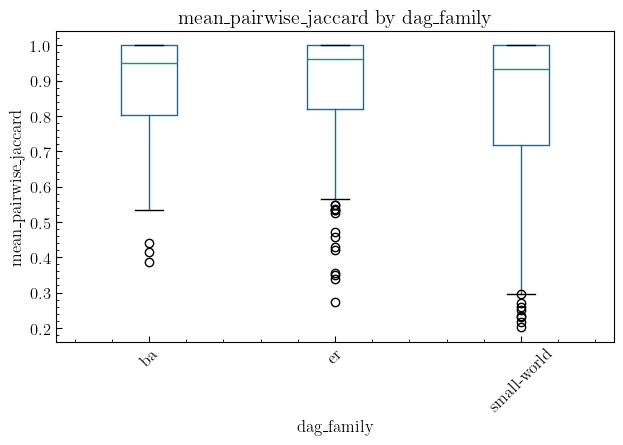

<Figure size 700x400 with 0 Axes>

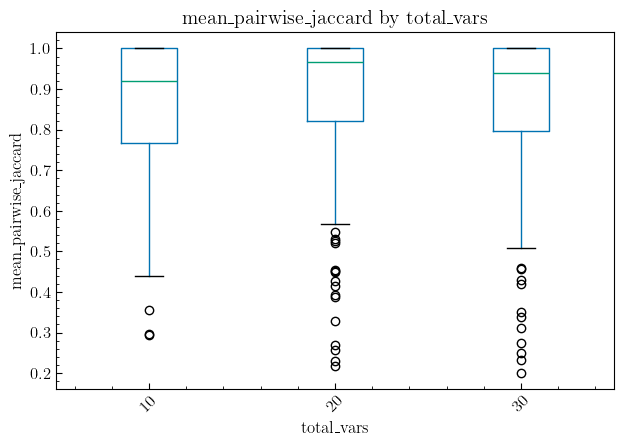

<Figure size 700x400 with 0 Axes>

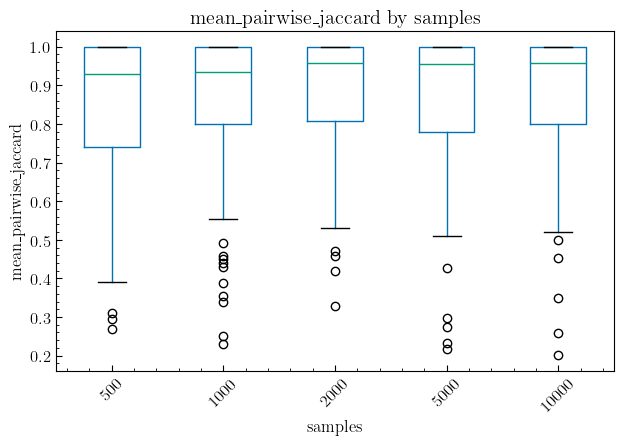

<Figure size 700x400 with 0 Axes>

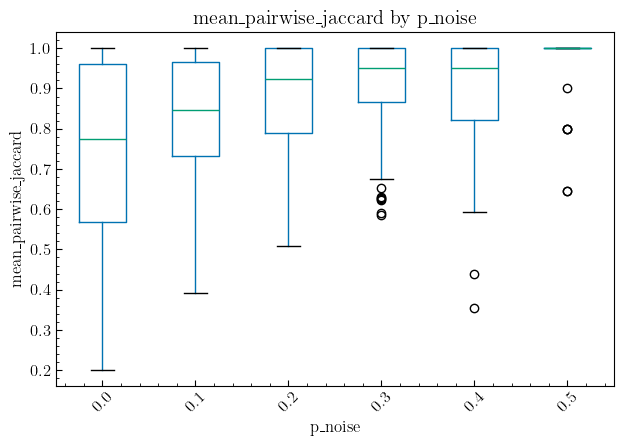

<Figure size 700x400 with 0 Axes>

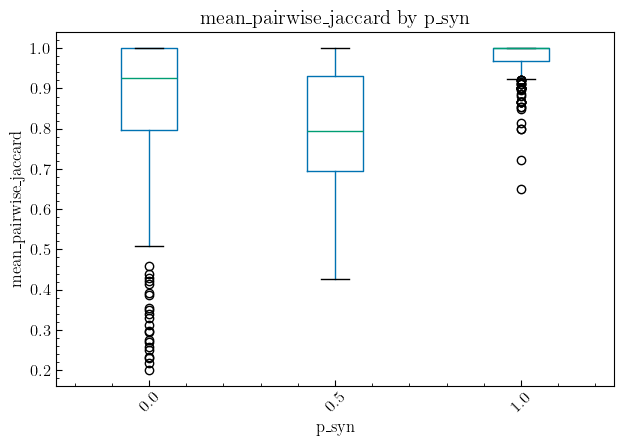

In [15]:
import matplotlib.pyplot as plt

for col in ["dag_family", "total_vars", "samples", "p_noise", "p_syn"]:
    plt.figure(figsize=(7, 4))
    stability_df.boxplot(column=target, by=col, grid=False)
    plt.title(f"{target} by {col}")
    plt.suptitle("")
    plt.ylabel(target)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [16]:
summary_2d = (
    stability_df.groupby(["samples", "p_noise"])[target]
    .mean()
    .unstack()
)

print(summary_2d)

p_noise       0.0       0.1       0.2       0.3       0.4       0.5
samples                                                            
500      0.718136  0.815081  0.867932  0.881910  0.906253  0.955144
1000     0.722783  0.817311  0.896752  0.941549  0.856015  1.000000
2000     0.781114  0.819871  0.894741  0.944326  0.883816  0.992593
5000     0.708512  0.831874  0.852023  0.895484  0.926520  1.000000
10000    0.751068  0.820511  0.872490  0.898006  0.942061  1.000000


In [17]:
import statsmodels.formula.api as smf

model = smf.ols(
    "mean_pairwise_jaccard ~ C(dag_family) + total_vars + samples + p_noise + p_syn",
    data=stability_df
).fit()

print(model.summary())

                              OLS Regression Results                             
Dep. Variable:     mean_pairwise_jaccard   R-squared:                       0.329
Model:                               OLS   Adj. R-squared:                  0.324
Method:                    Least Squares   F-statistic:                     65.49
Date:                   Sat, 04 Apr 2026   Prob (F-statistic):           3.11e-66
Time:                           15:20:47   Log-Likelihood:                 467.15
No. Observations:                    810   AIC:                            -920.3
Df Residuals:                        803   BIC:                            -887.4
Df Model:                              6                                         
Covariance Type:               nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

## Jpmf Data

In [18]:
subset = "jpmf_data"
load_results(subset)


In [19]:
algo_results = results_by_label["EA-FG"]

In [20]:
dir(algo_results[0])

['__annotations__',
 '__class__',
 '__dataclass_fields__',
 '__dataclass_params__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__match_args__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'algorithm',
 'bic_scores',
 'df_by_id',
 'ea_configurations',
 'eval_metrics',
 'experiment1_results',
 'experiment2_results',
 'folder',
 'learned_graphs',
 'max_score',
 'metadata_by_id',
 'replications',
 'true_graphs']

In [21]:
from metrics.graph import evaluate_colliders

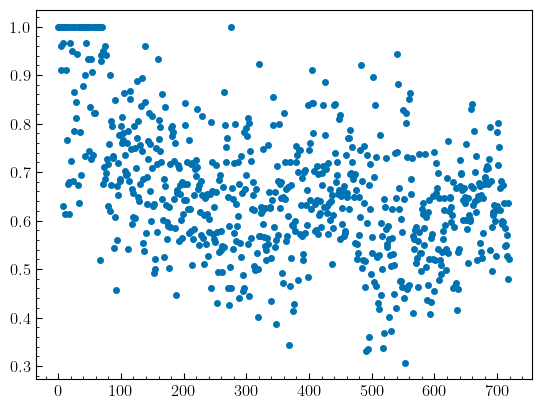

In [22]:
# idx = 89

jac_by_id = {}
for idx in algo_results[0].learned_graphs.keys():
    all_learned_graphs = [i.learned_graphs[idx] for i in algo_results]
    all_learned_edges = [set(g.edges()) for g in all_learned_graphs]
    jac_by_id[idx] = mean_pairwise_jaccard(all_learned_edges)
    
plt.scatter(list(jac_by_id.keys()), list(jac_by_id.values()), marker='o')

In [23]:

for idx in algo_results[0].learned_graphs.keys():
    all_learned_graphs = [res.learned_graphs[idx] for res in algo_results]
    

    jac = mean_pairwise_jaccard(all_learned_colliders)

    row = {"file_id": idx, "mean_pairwise_jaccard": jac}

    # add stored metadata from attrs
    row.update(algo_results[0].df_by_id[idx].attrs)

    rows.append(row)

In [24]:
# edges
from metrics.graph import colliders_directed_only


rows = []

for idx in algo_results[0].learned_graphs.keys():
    all_learned_graphs = [res.learned_graphs[idx] for res in algo_results]
    all_learned_colliders = [set(colliders_directed_only(g)) for g in all_learned_graphs]

    jac = mean_pairwise_jaccard(all_learned_colliders)

    row = {"file_id": idx, "mean_pairwise_jaccard": jac}

    # add stored metadata from attrs
    row.update(algo_results[0].df_by_id[idx].attrs)

    rows.append(row)

stability_df = pd.DataFrame(rows).sort_values("file_id").reset_index(drop=True)

In [25]:
stability_df

,file_id,mean_pairwise_jaccard,i,family,target_mi,pair_probs,syn_cutoff,num_vars
0,0,1.000000,0,er,0.316993,0.4,0.4,10
1,1,1.000000,1,er,0.316993,0.5,0.4,10
2,2,1.000000,2,er,0.316993,0.6,0.4,10
3,3,1.000000,3,er,0.316993,0.7,0.4,10
4,4,1.000000,4,er,0.475489,0.4,0.4,10
...,...,...,...,...,...,...,...,...
715,715,0.366276,715,small-world,0.792481,0.7,0.7,30
716,716,0.442661,716,small-world,0.950978,0.4,0.7,30
717,717,0.313601,717,small-world,0.950978,0.5,0.7,30
718,718,0.615377,718,small-world,0.950978,0.6,0.7,30


In [26]:
stability_df.groupby(["num_vars", "family"])["mean_pairwise_jaccard"].agg(
    ["mean", "std", "median", "min", "max"]
)

mean       std    median       min       max
num_vars family                                                       
10       ba           0.507682  0.197631  0.510741  0.096296  1.000000
         er           0.857602  0.203668  1.000000  0.288889  1.000000
         small-world  0.490703  0.222906  0.460291  0.074656  1.000000
20       ba           0.492812  0.165254  0.478899  0.170366  0.922222
         er           0.586243  0.172537  0.575397  0.227989  1.000000
         small-world  0.451671  0.141128  0.439137  0.155801  0.875926
30       ba           0.553972  0.141276  0.568580  0.187258  0.915309
         er           0.515155  0.132515  0.496894  0.219732  0.836728
         small-world  0.527393  0.130000  0.520305  0.244770  0.831538

In [27]:
stability_df.groupby(
    ["family", "num_vars", "target_mi", "syn_cutoff", "pair_probs"]
)["mean_pairwise_jaccard"].mean().reset_index()

,family,num_vars,target_mi,syn_cutoff,pair_probs,mean_pairwise_jaccard
0,ba,10,0.316993,0.4,0.4,0.455556
1,ba,10,0.316993,0.4,0.5,0.410370
2,ba,10,0.316993,0.4,0.6,0.470370
3,ba,10,0.316993,0.4,0.7,0.737037
4,ba,10,0.316993,0.5,0.4,0.562222
...,...,...,...,...,...,...
715,small-world,30,0.950978,0.6,0.7,0.498552
716,small-world,30,0.950978,0.7,0.4,0.442661
717,small-world,30,0.950978,0.7,0.5,0.313601
718,small-world,30,0.950978,0.7,0.6,0.615377


In [28]:
def iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)

target = "mean_pairwise_jaccard"

for col in ["family", "num_vars", "target_mi", "syn_cutoff", "pair_probs"]:
    print(f"\n--- {col} ---")
    print(
        stability_df.groupby(col)[target]
        .agg(mean="mean", std="std", iqr=iqr, median="median", n="count")
        .sort_values(["mean", "iqr"])
    )


--- family ---
                 mean       std       iqr    median    n
family                                                  
small-world  0.489923  0.171911  0.217404  0.479169  240
ba           0.518156  0.170926  0.222938  0.521504  240
er           0.653000  0.226318  0.370139  0.597407  240

--- num_vars ---
              mean       std       iqr    median    n
num_vars                                             
20        0.510242  0.169215  0.201581  0.497169  240
30        0.532174  0.135098  0.176493  0.521596  240
10        0.618663  0.267879  0.440509  0.598122  240

--- target_mi ---
               mean       std       iqr    median    n
target_mi                                             
0.950978   0.491260  0.194119  0.217455  0.458414  144
0.792481   0.510209  0.205962  0.204029  0.466667  144
0.633985   0.525305  0.204264  0.222482  0.500737  144
0.475489   0.586652  0.190354  0.224455  0.572593  144
0.316993   0.655039  0.182169  0.240238  0.639943  144

--- sy

<Figure size 700x400 with 0 Axes>

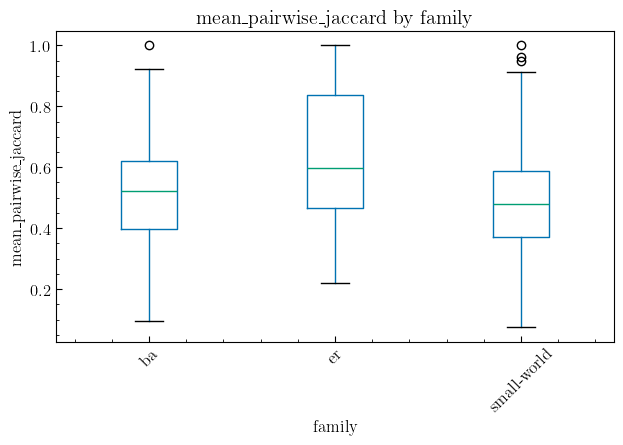

<Figure size 700x400 with 0 Axes>

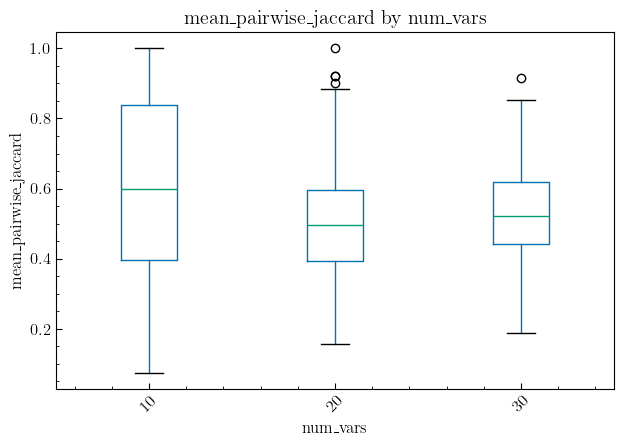

<Figure size 700x400 with 0 Axes>

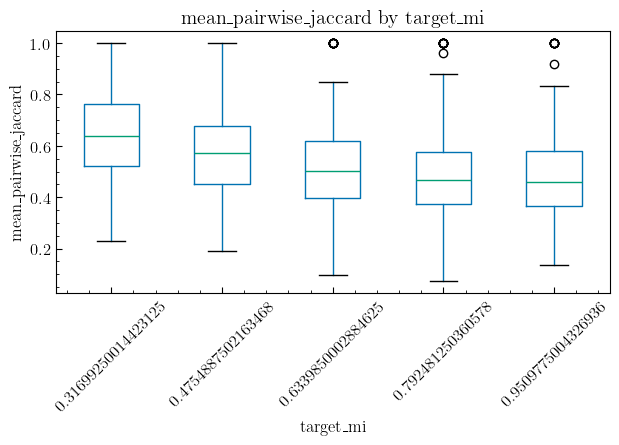

<Figure size 700x400 with 0 Axes>

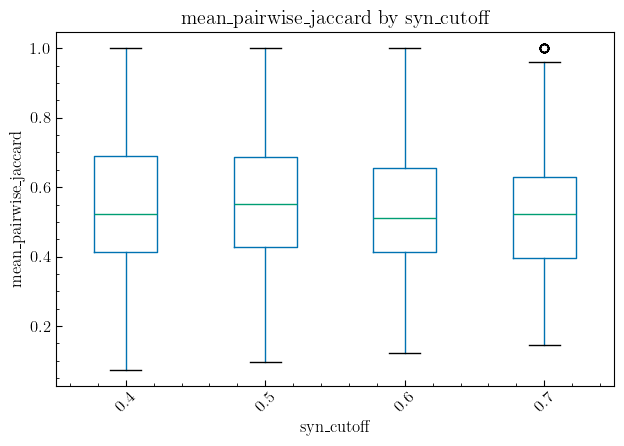

<Figure size 700x400 with 0 Axes>

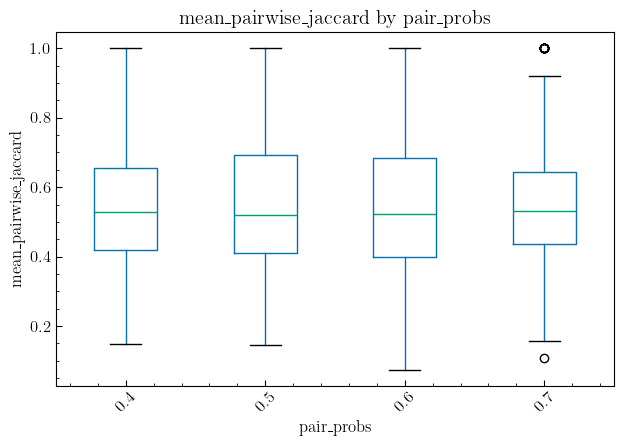

In [29]:
import matplotlib.pyplot as plt

for col in ["family", "num_vars", "target_mi", "syn_cutoff", "pair_probs"]:
    plt.figure(figsize=(7, 4))
    stability_df.boxplot(column=target, by=col, grid=False)
    plt.title(f"{target} by {col}")
    plt.suptitle("")
    plt.ylabel(target)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [30]:
summary_2d = (
    stability_df.groupby(["family", "num_vars", "target_mi", "syn_cutoff", "pair_probs"])[target]
    .mean()
    .unstack()
)

print(summary_2d)

pair_probs                                      0.4       0.5       0.6  \
family      num_vars target_mi syn_cutoff                                 
ba          10       0.316993  0.4         0.455556  0.410370  0.470370   
                               0.5         0.562222  0.229630  0.306296   
                               0.6         0.511111  0.481852  0.807407   
                               0.7         0.731481  0.770370  0.434815   
                     0.475489  0.4         0.397196  0.666296  0.351852   
...                                             ...       ...       ...   
small-world 30       0.792481  0.7         0.534864  0.490731  0.368002   
                     0.950978  0.4         0.433333  0.397670  0.592466   
                               0.5         0.273918  0.424661  0.347589   
                               0.6         0.441027  0.410690  0.244770   
                               0.7         0.442661  0.313601  0.615377   

pair_probs              

In [31]:
import statsmodels.formula.api as smf

model = smf.ols(
    "mean_pairwise_jaccard ~ C(family) + num_vars + target_mi + syn_cutoff + pair_probs",
    data=stability_df
).fit()

print(model.summary())

                              OLS Regression Results                             
Dep. Variable:     mean_pairwise_jaccard   R-squared:                       0.231
Model:                               OLS   Adj. R-squared:                  0.225
Method:                    Least Squares   F-statistic:                     35.75
Date:                   Sat, 04 Apr 2026   Prob (F-statistic):           6.71e-38
Time:                           15:21:00   Log-Likelihood:                 217.94
No. Observations:                    720   AIC:                            -421.9
Df Residuals:                        713   BIC:                            -389.8
Df Model:                              6                                         
Covariance Type:               nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

## Jpmf Data